# Perturbation LOO Benchmark — Bar Plots

Visualises the `benchmark_{slide_id}.csv` produced by `run_perturb_loo.sh`.

**Two panels per metric:**
1. Per holdout-cell-type bars, one bar per method.
2. Summary bars (mean ± SEM across holdout types).

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({'figure.dpi': 300, 'font.size': 11})
sns.set_style('whitegrid')

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
out_dir   = './results/perturb_benchmark'
slide_ids = [242]   # set to None to load all slides in out_dir

metrics = ['pearson_r', 'spearman_r', 'precision']

method_order = ['cellina_cf', 'cellina_perturb', 'spatialprop']
method_labels = {
    'cellina_cf':      'Cellina\n(Edge Pert.)',
    'cellina_perturb': 'Cellina\n(Neigh. Pert.)',
    'spatialprop':     'SpatialProp',
}
method_colors = {
    'cellina_cf':      '#B71C1C',  # dark red
    'cellina_perturb': '#B71C1C',  # same dark red (striped will differentiate it)
    'spatialprop':     'gray',
}

method_hatches = {
    'cellina_cf':      None,
    'cellina_perturb': '///',
    'spatialprop':     None,
}

In [4]:
# ── Load data ─────────────────────────────────────────────────────────────────
if slide_ids is None:
    files = sorted(glob.glob(os.path.join(out_dir, 'benchmark_*.csv')))
else:
    files = [
        os.path.join(out_dir, f'benchmark_{sid}.csv')
        for sid in slide_ids
        if os.path.exists(os.path.join(out_dir, f'benchmark_{sid}.csv'))
    ]

if not files:
    raise FileNotFoundError(f"No benchmark CSVs found in {out_dir}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Loaded {len(df)} rows from {len(files)} file(s)")
print()
print(df.groupby(['method', 'is_holdout']).size().rename('count').to_string())

Loaded 50 rows from 1 file(s)

method           is_holdout
cellina_cf       True           5
cellina_perturb  False         35
                 True           5
spatialprop      True           5


In [5]:
# ── Prepare holdout-only view ─────────────────────────────────────────────────
# For the cross-method comparison we want:
#   - each row is one (holdout_celltype, method) pair
#   - for cellina_perturb, keep only the row where cell_type == holdout_celltype
df_holdout = df[df['is_holdout']].copy()
df_holdout = df_holdout[
    df_holdout['cell_type'] == df_holdout['holdout_celltype']
].reset_index(drop=True)

holdout_types = sorted(df_holdout['holdout_celltype'].unique())
available_methods = [m for m in method_order if m in df_holdout['method'].unique()]

top_n_perturb = int(df_holdout['top_n_perturb'].iloc[0])
top_n         = int(df_holdout['top_n'].iloc[0])

print(f"Holdout types: {holdout_types}")
print(f"Methods:       {available_methods}")
print(f"top_n_perturb={top_n_perturb}, top_n={top_n}")
df_holdout.head()

Holdout types: ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
Methods:       ['cellina_cf', 'cellina_perturb', 'spatialprop']
top_n_perturb=100, top_n=100


,slide_id,holdout_celltype,cell_type,method,is_holdout,n_ref,n_crc,pearson_r,spearman_r,precision,mixing_index,edistance,top_n_perturb,top_n
0,242,Fibroblast,Fibroblast,cellina_perturb,True,6100,22548,0.801940,0.718008,0.45,0.764308,296.179688,100,100
1,242,Fibroblast,Fibroblast,cellina_cf,True,6100,22548,0.892787,0.757564,0.51,0.727542,253.773743,100,100
2,242,Endothelial,Endothelial,cellina_perturb,True,982,1642,0.947081,0.845485,0.68,0.577962,109.716583,100,100
3,242,Endothelial,Endothelial,cellina_cf,True,982,1642,0.981837,0.912043,0.75,0.670941,57.184509,100,100
4,242,Myeloid,Myeloid,cellina_perturb,True,1615,4147,0.926423,0.854065,0.57,0.868365,87.975098,100,100


In [6]:
metric_labels = {
    'pearson_r':   'Pearson r',
    'spearman_r':  'Spearman ρ',
    'precision':   f'Precision@{top_n}',
}

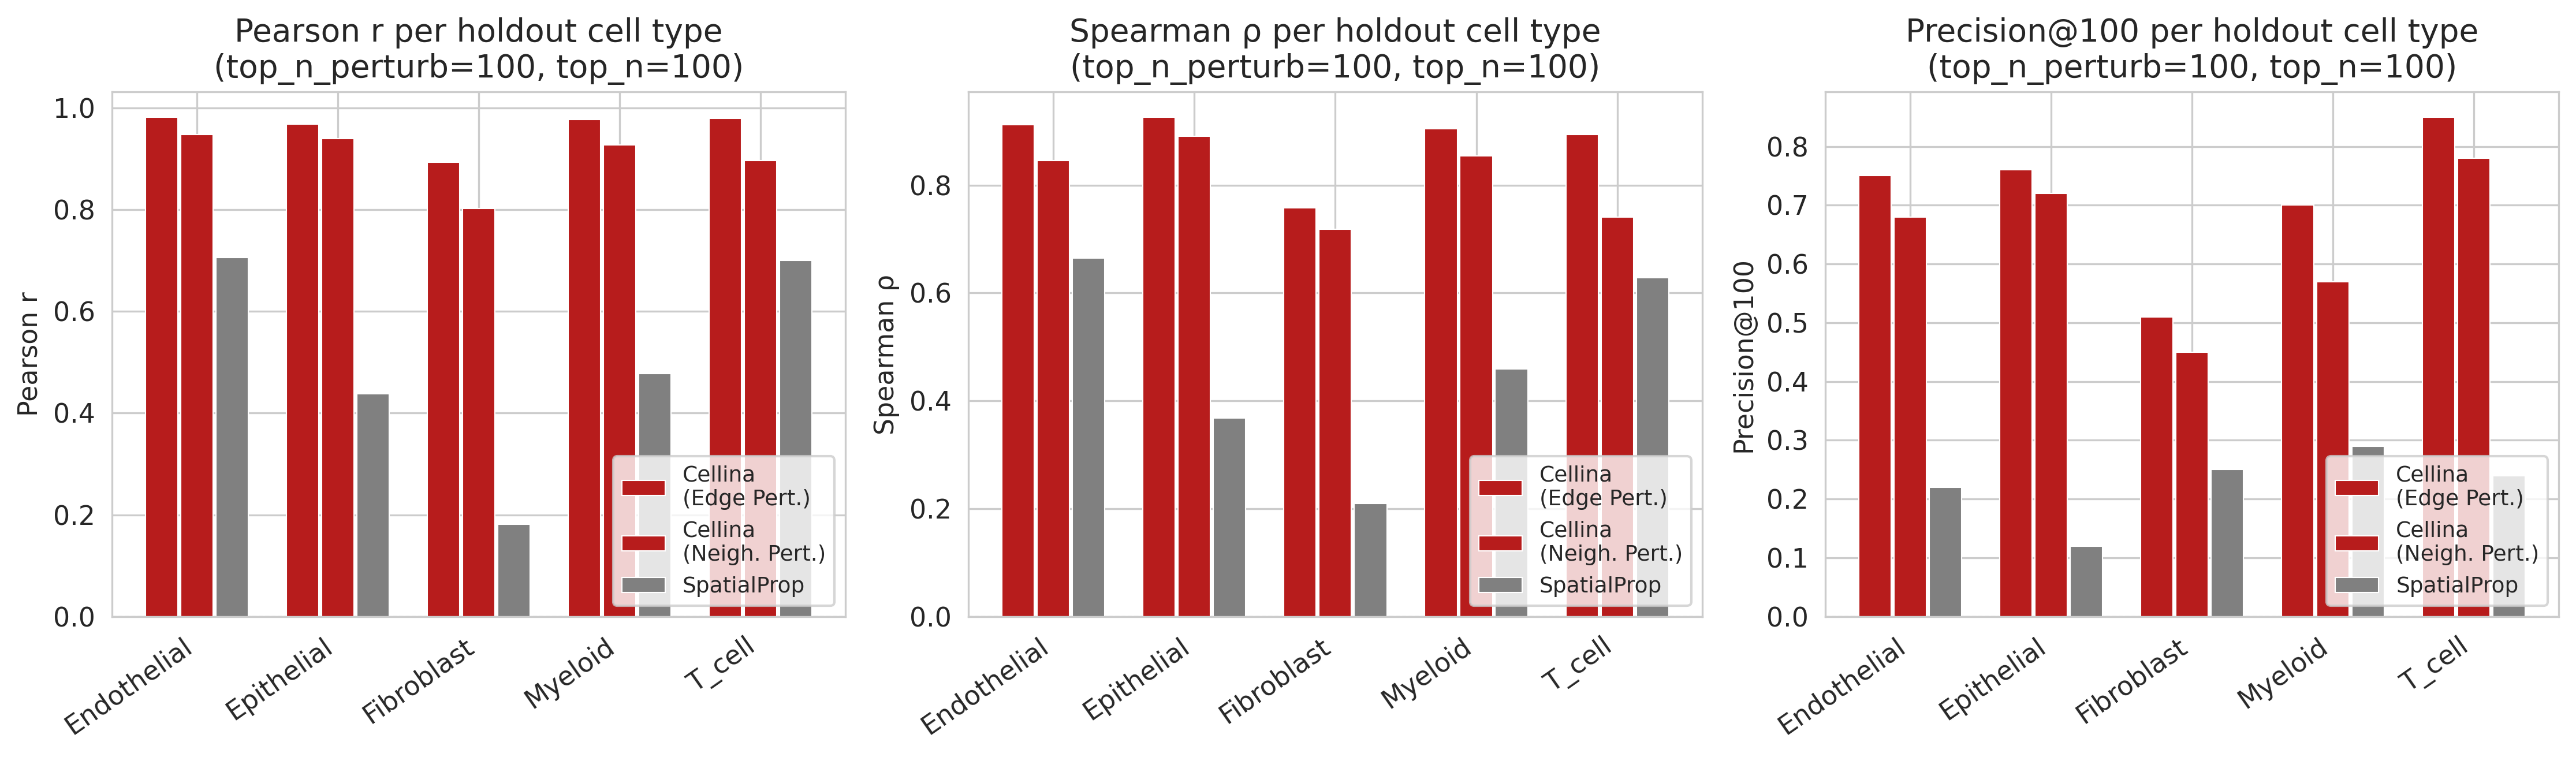

In [7]:
# ── Per-cell-type bar plot ────────────────────────────────────────────────────
n_metrics = len(metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4.5), sharey=False)
axes = [axes] if n_metrics == 1 else list(axes)

x = np.arange(len(holdout_types))
width = 0.75 / len(available_methods)

for ax, metric in zip(axes, metrics):
    for i, method in enumerate(available_methods):
        vals = [
            df_holdout[
                (df_holdout['holdout_celltype'] == ct) &
                (df_holdout['method'] == method)
            ][metric].values
            for ct in holdout_types
        ]
        # Take mean if multiple slides; NaN if missing
        vals = [v.mean() if len(v) > 0 else np.nan for v in vals]

        offset = (i - len(available_methods) / 2 + 0.5) * width
        ax.bar(
            x + offset, vals, width * 0.92,
            label=method_labels.get(method, method),
            color=method_colors.get(method, None),
            edgecolor='white', linewidth=0.5,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(holdout_types, rotation=35, ha='right')
    ax.set_ylabel(metric_labels.get(metric, metric))
    ax.set_title(
        f"{metric_labels.get(metric, metric)} per holdout cell type\n"
        f"(top_n_perturb={top_n_perturb}, top_n={top_n})"
    )
    ax.legend(fontsize=9, loc='lower right')
    ax.axhline(0, color='grey', lw=0.5, ls='--')

plt.tight_layout()
slide_tag = slide_ids[0] if slide_ids else 'all'
fig.savefig(
    os.path.join(out_dir, f'benchmark_{slide_tag}_per_ct.pdf'),
    bbox_inches='tight',
)
plt.show()

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# ── Nature Methods global style ───────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "monospace",
    "font.size":          7,
    "axes.titlesize":     7,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "hatch.linewidth":    0.6,   # controls hatch stroke weight globally
})

# ── Layout ────────────────────────────────────────────────────────────────────
panel_w   = 1.8
fig_h     = 2.2
fig, axes = plt.subplots(
    1, n_metrics,
    figsize=(panel_w * n_metrics, fig_h),
    sharey=False,
)
axes = [axes] if n_metrics == 1 else list(axes)

bar_w  = 0.55
dot_kw = dict(s=8, zorder=4, color="black", alpha=0.5, linewidths=0)

for ax, metric in zip(axes, metrics):
    means, sems, all_pts = [], [], []
    for method in available_methods:
        vals = (
            df_holdout[df_holdout["method"] == method]
            .groupby("holdout_celltype")[metric]
            .mean()
            .dropna()
            .values
        )
        means.append(np.mean(vals))
        sems.append(np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)
        all_pts.append(vals)

    xi = np.arange(len(available_methods))

    # bars — draw one at a time so hatch/edgecolor can differ per bar
    for j, method in enumerate(available_methods):
        hatch = method_hatches[method]
        ax.bar(
            xi[j], means[j], bar_w,
            color=method_colors[method],
            hatch=hatch,
            # white outline separates bars; hatch color inherits from edgecolor
            # use a slightly lighter red so hatch lines read on dark fill
            edgecolor="white" if hatch is None else "black",
            linewidth=0.5,
            zorder=2,
        )

    # error bars
    ax.errorbar(
        xi, means, yerr=sems,
        fmt="none",
        ecolor="black", elinewidth=0.8, capsize=2, capthick=0.8,
        zorder=3,
    )

    # individual holdout dots with jitter
    rng = np.random.default_rng(0)
    for j, pts in enumerate(all_pts):
        jitter = rng.uniform(-0.07, 0.07, size=len(pts))
        ax.scatter(xi[j] + jitter, pts, **dot_kw)

    # zero line
    ax.axhline(0, color="black", lw=0.4, ls="--", zorder=1)

    # axes ticks & labels
    ax.set_xticks(xi)
    ax.set_xticklabels(
        [method_labels.get(m, m) for m in available_methods],
        rotation=35, ha="right", rotation_mode="anchor",
    )
    ax.set_title(metric_labels.get(metric, metric), pad=3)
    # ax.set_ylabel(metric_labels.get(metric, metric))

    # y-axis: always reach 1; dip below 0 if data requires
    ymin = min(0, min(m - s for m, s in zip(means, sems))) * 1.15
    ax.set_ylim(bottom=ymin, top=1.0)
    ax.yaxis.set_major_locator(mpl.ticker.FixedLocator(
        np.round(np.linspace(max(0, ymin), 1.0, 5), 2)
    ))

# ── Shared legend below all panels ───────────────────────────────────────────
handles = [
    mpl.patches.Patch(
        facecolor=method_colors[m],
        hatch=method_hatches[m],
        edgecolor="white" if method_hatches[m] is None else "black",
        linewidth=0.5,
        label=method_labels.get(m, m),
    )
    for m in available_methods
]
# fig.legend(
#     handles=handles,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.02),
#     ncol=len(available_methods),
#     frameon=False,
#     handlelength=1.2,
#     handleheight=0.9,
#     columnspacing=0.8,
# )

plt.tight_layout(rect=[0, 0.10, 1, 1])
fig.savefig(
    os.path.join(out_dir, f"benchmark_{slide_tag}_summary.svg"),
    bbox_inches="tight", dpi=300,
)
plt.show()